In [65]:
import random
from collections import deque

SIZE_OF_REWARD_QUEUE = 4  # Window size
rewards_queue = deque(maxlen=SIZE_OF_REWARD_QUEUE)
RESOURCE_MAX = 100
R_NEW = 0
R_OLD = 60
resource_count = SIZE_OF_REWARD_QUEUE 
difference_sum = 0
resource_flag = False
old_gradient = 0

random.seed(10)

In [66]:
def REWARD_ACCUMULATION(reward):
    rewards_queue.append(reward)
    if(len(rewards_queue) == rewards_queue.maxlen):
        for i in range(len(rewards_queue)-1):
            difference_sum += (rewards_queue[i] - rewards_queue[i+1])
        old_gradient =  difference_sum - (rewards_queue[0] - rewards_queue[1])
        resource_flag = True

In [59]:
def RESOURCE_CALC_1(reward):
    rewards_queue.append(reward)
    
    if(len(rewards_queue) == rewards_queue.maxlen):     
        difference_sum = 0
        for i in range(len(rewards_queue)-1):
            difference_sum += (rewards_queue[i] - rewards_queue[i+1])
            print(f"{rewards_queue[i]} - {rewards_queue[i+1]} = {difference_sum}")
        squeezing_factor =  difference_sum/SIZE_OF_REWARD_QUEUE
        print(squeezing_factor)
        R_NEW = (R_OLD + ((R_OLD/RESOURCE_MAX)* squeezing_factor))
        
        return R_NEW
    else:
        return None


In [67]:
def RESOURCE_CALC(reward):
    rewards_queue.append(reward)
    difference_sum = old_gradient + (rewards_queue[-2] - rewards_queue[-1])
    old_gradient =  difference_sum - (rewards_queue[0] - rewards_queue[1])
    print(f"difference sum = {difference_sum}")
    squeezing_factor =  difference_sum/SIZE_OF_REWARD_QUEUE
    print(squeezing_factor)
    R_NEW = (R_OLD + ((R_OLD/RESOURCE_MAX)* squeezing_factor))

    return R_NEW



In [63]:
random_values = [random.randint(0, 55) for _ in range(50)]


In [69]:
for reward in random_values:
    if not resource_flag:
         REWARD_ACCUMULATION(reward)
    else:
        R_NEW = RESOURCE_CALC(reward)

    print(f"Added reward: {reward}, Queue: {list(rewards_queue)}, R_NEW: {R_NEW}")

UnboundLocalError: local variable 'difference_sum' referenced before assignment

In [55]:
for reward in random_values:
    gradient = RESOURCE_CALC(reward)
    print(f"Added reward: {reward}, Queue: {list(rewards_queue)}, R_NEW: {gradient}")

Added reward: 36, Queue: [36], R_NEW: None
Added reward: 2, Queue: [36, 2], R_NEW: None
Added reward: 27, Queue: [36, 2, 27], R_NEW: None
36 - 2 = 34
2 - 27 = 9
27 - 30 = 6
-7.75
Added reward: 30, Queue: [36, 2, 27, 30], R_NEW: 55.35
-3.0
Added reward: 36, Queue: [2, 27, 30, 36], R_NEW: 58.2
6.75
Added reward: 0, Queue: [27, 30, 36, 0], R_NEW: 64.05
5.0
Added reward: 13, Queue: [30, 36, 0, 13], R_NEW: 63.0
-8.0
Added reward: 29, Queue: [36, 0, 13, 29], R_NEW: 55.2
-10.5
Added reward: 52, Queue: [0, 13, 29, 52], R_NEW: 53.7
-1.25
Added reward: 31, Queue: [13, 29, 52, 31], R_NEW: 59.25
-0.75
Added reward: 52, Queue: [29, 52, 31, 52], R_NEW: 59.55
2.75
Added reward: 17, Queue: [52, 31, 52, 17], R_NEW: 61.65
2.0
Added reward: 41, Queue: [31, 52, 17, 41], R_NEW: 61.2
-9.25
Added reward: 51, Queue: [52, 17, 41, 51], R_NEW: 54.45
7.0
Added reward: 10, Queue: [17, 41, 51, 10], R_NEW: 64.2
11.5
Added reward: 2, Queue: [41, 51, 10, 2], R_NEW: 66.9
-6.5
Added reward: 33, Queue: [51, 10, 2, 33], R

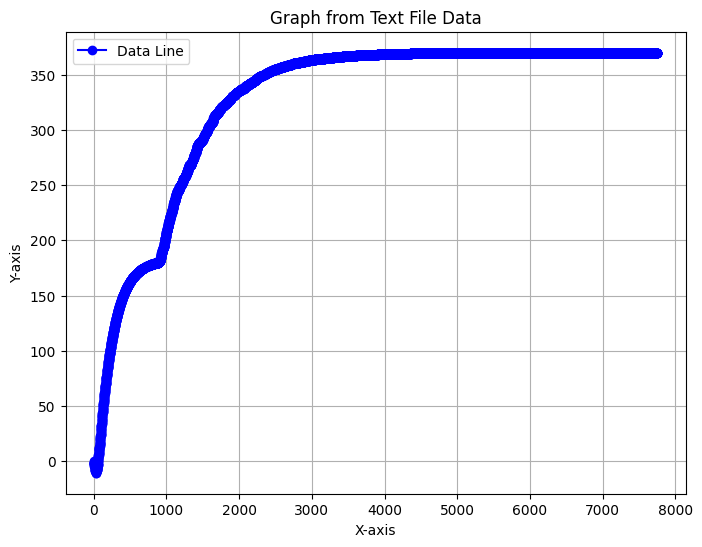

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Read the data from the text file
cummulative_filename = "qsumfile.txt"  
c_reward = np.loadtxt(cummulative_filename)

# Assuming the first column is X and the second column is Y
x = c_reward[:, 0]
y = c_reward[:, 1]

# Plot the data
plt.figure(figsize=(8, 6))
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Data Line')

# Customize the graph
plt.title("Graph from Text File Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()

# Show the plot
plt.show()

In [62]:
from collections import deque
import numpy as np

def read_column_from_file(file_name, column_index=1, limit=5100):
    """
    Reads a specific column from a text file, limiting to the first 'limit' values.
    """
    values = []
    with open(file_name, 'r') as file:
        for i, line in enumerate(file):
            if i >= limit:  # Stop after reading 'limit' lines
                break
            if line.strip():  # Skip empty lines
                columns = line.split()
                values.append(float(columns[column_index]))
    return values

def find_saturation_point(values, queue_size=100, threshold=0.1):
    """
    Iteratively adds values to a queue and checks for saturation.
    """
    queue = deque(maxlen=queue_size)
    saturation_point = -1  # Initialize to -1 if no saturation is found

    for i, value in enumerate(values):
        queue.append(value)
        if len(queue) == queue_size:
            std_dev = np.std(queue)
            if std_dev < threshold:
                saturation_point = i  # Store the index where saturation occurs
                break
    return saturation_point, list(queue)

# Main execution
if __name__ == "__main__":
    # Replace 'data.txt' with your file name
    file_name = 'qsumfile.txt'
    
    # Read the second column (index 1) from the file, limited to the first 3000 rows
    values = read_column_from_file(file_name, column_index=1, limit=8000)
    
    # Define queue size and saturation threshold
    queue_size = 100
    threshold = 0.5

    # Find saturation point
    saturation_point, saturated_queue = find_saturation_point(values, queue_size, threshold)
    
    if saturation_point != -1:
        print(f"Saturation point found at index {saturation_point} with queue: {saturated_queue}")
    else:
        print("No saturation point found.")


Saturation point found at index 897 with queue: [178.35345772413132, 178.37490285438753, 178.39630278992885, 178.41765366066292, 178.43902938568675, 178.4606139312193, 178.48252032690195, 178.50459009008588, 178.5264187591244, 178.54765207547717, 178.5683123378445, 178.5886829518522, 178.6090104373761, 178.62929500728794, 178.64961238708602, 178.67013379784945, 178.69095304212303, 178.7119072624405, 178.7326147303928, 178.7527577282287, 178.77237049505968, 178.79172042194278, 178.8110293874099, 178.83030136932044, 178.8496130816769, 178.86912331357766, 178.88890834443976, 178.90880251612307, 178.92844638717196, 178.94755572356578, 178.96617471005783, 178.98455509252597, 179.0028967605419, 179.0212071298792, 179.03956318259503, 179.05811164284881, 179.07691287920886, 179.09579982727632, 179.11443477804, 179.13256413011902, 179.15024023708528, 179.1676996647074, 179.18512268438863, 179.202519819428, 179.21996768988495, 179.23760136593137, 179.25546682605878, 179.27339682685766, 179.29107

reached saturation point: 7, standard_deviation: 0.49745882302047123 saturation point: 179.4659464607796 
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$